### Trabajo Final: Aplicación de Módulos y Paquetes en Python para Machine Learning en un Contexto Empresarial

**Caso práctico:** Empresa de análisis de datos financieros — clasificación de opiniones (positivas/negativas) y predicción de tendencias de mercado.

**Librerías requeridas **
```
pip install pandas numpy scikit-learn matplotlib seaborn spacy nltk transformers torch tensorflow
python -m spacy download es_core_news_sm
```
En Python, también ejecutar una vez:
```python
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
```

## 0. Diagrama de arquitectura de la solución

```
Datos (CSV) --> Pandas/Numpy (carga y limpieza) --> Preprocesamiento
   (spaCy: tokenización/lematización, StandardScaler: variables numéricas)
   --> Modelo NLP (TF-IDF + clasificador) / Modelo Deep Learning (Keras, serie de tiempo)
   --> Evaluación (accuracy, matriz de confusión) --> Visualización (Matplotlib/Seaborn)
```
La celda siguiente genera este diagrama como imagen.

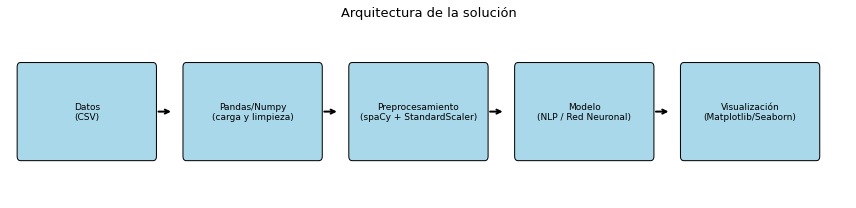

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 3))
pasos = ["Datos\n(CSV)", "Pandas/Numpy\n(carga y limpieza)", "Preprocesamiento\n(spaCy + StandardScaler)",
         "Modelo\n(NLP / Red Neuronal)", "Visualización\n(Matplotlib/Seaborn)"]
x = 0
for i, paso in enumerate(pasos):
    ax.add_patch(mpatches.FancyBboxPatch((x, 0), 2, 1, boxstyle="round,pad=0.05", fc="#a8d8ea", ec="black"))
    ax.text(x + 1, 0.5, paso, ha="center", va="center", fontsize=9)
    if i < len(pasos) - 1:
        ax.annotate("", xy=(x + 2.3, 0.5), xytext=(x + 2.05, 0.5),
                     arrowprops=dict(arrowstyle="->", lw=2))
    x += 2.5
ax.set_xlim(-0.2, x)
ax.set_ylim(-0.5, 1.5)
ax.axis("off")
ax.set_title("Arquitectura de la solución", fontsize=13)
plt.tight_layout()
plt.savefig("diagrama_arquitectura.png", dpi=150)
plt.show()

## 1. Manipulación y análisis de datos con Pandas y Numpy

Carga del dataset de opiniones (`opiniones_financieras.csv`) y del dataset de serie de tiempo (`tendencia_mercado.csv`).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import spacy

sns.set_style("whitegrid")

OSError: [WinError 1114] Error en una rutina de inicialización de biblioteca de vínculos dinámicos (DLL). Error loading "c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
df = pd.read_csv("opiniones_financieras.csv")
print(df.shape)
df.head()

(240, 3)


,texto,sentimiento,num_palabras
0,el fondo de inversion tiene una plataforma muy...,positivo,13
1,"Excelente atencion al cliente, la cooperativa ...",positivo,11
2,El equipo de la casa de bolsa fue muy profesio...,positivo,16
3,Estoy feliz con la rentabilidad que me ha dado...,positivo,14
4,Estoy feliz con la rentabilidad que me ha dado...,positivo,15


In [ ]:
# Exploración básica con Pandas/Numpy
print(df.info())
print("\nDistribución de clases:")
print(df["sentimiento"].value_counts())
print("\nEstadísticos de num_palabras:")
print(df["num_palabras"].describe())

# Transformación: variable binaria (0 = negativo, 1 = positivo)
df["label"] = np.where(df["sentimiento"] == "positivo", 1, 0)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   texto         240 non-null    object
 1   sentimiento   240 non-null    object
 2   num_palabras  240 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.8+ KB
None

Distribución de clases:
sentimiento
positivo    120
negativo    120
Name: count, dtype: int64

Estadísticos de num_palabras:
count    240.000000
mean      12.875000
std        1.804515
min        9.000000
25%       12.000000
50%       13.000000
75%       14.000000
max       17.000000
Name: num_palabras, dtype: float64


,texto,sentimiento,num_palabras,label
0,el fondo de inversion tiene una plataforma muy...,positivo,13,1
1,"Excelente atencion al cliente, la cooperativa ...",positivo,11,1
2,El equipo de la casa de bolsa fue muy profesio...,positivo,16,1
3,Estoy feliz con la rentabilidad que me ha dado...,positivo,14,1
4,Estoy feliz con la rentabilidad que me ha dado...,positivo,15,1


## 2. Preprocesamiento NLP (spaCy) + escalado de variables numéricas (StandardScaler)

Se limpia y lematiza el texto con spaCy (igual que en los talleres previos) y se escala la variable numérica `num_palabras` con `StandardScaler`, tal como pide el entregable.

In [ ]:
nlp = spacy.load("es_core_news_sm")

def limpiar_lematizar(texto):
    doc = nlp(texto.lower())
    tokens = [t.lemma_ for t in doc if t.is_alpha and not t.is_stop]
    return " ".join(tokens)

df["texto_limpio"] = df["texto"].apply(limpiar_lematizar)
df[["texto", "texto_limpio"]].head()

NameError: name 'spacy' is not defined

In [ ]:
X_train_txt, X_test_txt, y_train, y_test, num_train, num_test = train_test_split(
    df["texto_limpio"], df["label"], df[["num_palabras"]],
    test_size=0.2, random_state=42, stratify=df["label"]
)

# TF-IDF sobre el texto (ajustado SOLO con train)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_txt)
X_test_tfidf = vectorizer.transform(X_test_txt)

# StandardScaler sobre la variable numérica (ajustado SOLO con train)
scaler = StandardScaler()
num_train_scaled = scaler.fit_transform(num_train)
num_test_scaled = scaler.transform(num_test)

# Combinar features de texto (TF-IDF) + feature numérica escalada
X_train_final = hstack([X_train_tfidf, num_train_scaled])
X_test_final = hstack([X_test_tfidf, num_test_scaled])

print("Shape train:", X_train_final.shape, " Shape test:", X_test_final.shape)

## 3. Modelo de clasificación (Scikit-learn) — validación del modelo

In [ ]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_final, y_train)

y_pred = modelo.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Clasificador de opiniones")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150)
plt.show()

## 3.1 Prueba con nuevas opiniones (extracción de info de reportes / análisis de sentimiento)

In [ ]:
nuevas_opiniones = [
    "El servicio al cliente del banco fue rapido y muy profesional",
    "La plataforma se cayo justo cuando iba a vender mis acciones, pesimo",
    "Estoy conforme con la rentabilidad obtenida este mes",
    "Nunca mas invierto con esta fintech, perdi dinero por sus comisiones ocultas"
]

nuevas_limpias = [limpiar_lematizar(t) for t in nuevas_opiniones]
nuevas_tfidf = vectorizer.transform(nuevas_limpias)
nuevas_num = scaler.transform(pd.DataFrame({"num_palabras": [len(t.split()) for t in nuevas_opiniones]}))
nuevas_final = hstack([nuevas_tfidf, nuevas_num])

predicciones = modelo.predict(nuevas_final)
for texto, pred in zip(nuevas_opiniones, predicciones):
    print(f"{texto!r} -> {'positivo' if pred == 1 else 'negativo'}")

## 4. Análisis de sentimiento con Transformers (alternativa/comparación con el modelo clásico)

Igual que en `taller_nlp2_fixed.ipynb`, se usa un modelo preentrenado en español para comparar contra el modelo TF-IDF + Logistic Regression.

In [ ]:
import torch
from transformers import pipeline

analizador = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis",
    device=-1
)

resultados_transformers = analizador(nuevas_opiniones)
for texto, res in zip(nuevas_opiniones, resultados_transformers):
    print(f"{texto!r} -> {res['label']} ({res['score']:.2f})")

## 5. Deep Learning (TensorFlow/Keras): red neuronal para predecir tendencia de mercado (serie de tiempo)

In [ ]:
df_ts = pd.read_csv("tendencia_mercado.csv", parse_dates=["fecha"])
df_ts.head()

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_ts["fecha"], df_ts["precio_cierre"], label="Precio de cierre")
plt.plot(df_ts["fecha"], df_ts["media_movil_10"], label="Media móvil (10 días)", linestyle="--")
plt.title("Evolución del precio de mercado")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.tight_layout()
plt.savefig("tendencia_mercado.png", dpi=150)
plt.show()

In [ ]:
# Preparar ventanas de tiempo (usar los últimos N días para predecir el siguiente precio)
precios = df_ts["precio_cierre"].values.astype("float32")

scaler_ts = StandardScaler()
precios_scaled = scaler_ts.fit_transform(precios.reshape(-1, 1)).flatten()

N = 10  # tamaño de ventana
X_seq, y_seq = [], []
for i in range(len(precios_scaled) - N):
    X_seq.append(precios_scaled[i:i+N])
    y_seq.append(precios_scaled[i+N])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split = int(len(X_seq) * 0.8)
X_train_ts, X_test_ts = X_seq[:split], X_seq[split:]
y_train_ts, y_test_ts = y_seq[:split], y_seq[split:]

print("Train:", X_train_ts.shape, " Test:", X_test_ts.shape)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

modelo_nn = keras.Sequential([
    layers.Input(shape=(N,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)  # regresión: predice el siguiente precio (escalado)
])

modelo_nn.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_nn.summary()

In [ ]:
historial = modelo_nn.fit(
    X_train_ts, y_train_ts,
    validation_data=(X_test_ts, y_test_ts),
    epochs=50, batch_size=16, verbose=1
)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(historial.history["loss"], label="Pérdida (train)")
plt.plot(historial.history["val_loss"], label="Pérdida (validación)")
plt.title("Curva de entrenamiento de la red neuronal")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig("curva_entrenamiento.png", dpi=150)
plt.show()

In [ ]:
y_pred_ts = modelo_nn.predict(X_test_ts).flatten()

# Volver a la escala original de precios
y_test_real = scaler_ts.inverse_transform(y_test_ts.reshape(-1, 1)).flatten()
y_pred_real = scaler_ts.inverse_transform(y_pred_ts.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_test_real, label="Precio real")
plt.plot(y_pred_real, label="Precio predicho", linestyle="--")
plt.title("Comparación: tendencia real vs. predicha")
plt.xlabel("Día (conjunto de prueba)")
plt.ylabel("Precio de cierre")
plt.legend()
plt.tight_layout()
plt.savefig("prediccion_vs_real.png", dpi=150)
plt.show()

## 6. Gráficos comparativos adicionales (histogramas, dispersión, líneas de tendencia)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma: longitud de las opiniones por clase
sns.histplot(data=df, x="num_palabras", hue="sentimiento", multiple="stack", ax=axes[0])
axes[0].set_title("Histograma: longitud de opiniones por sentimiento")

# Histograma: retornos diarios del mercado
sns.histplot(df_ts["retorno_diario"], bins=30, ax=axes[1], color="orange")
axes[1].set_title("Histograma: retornos diarios del mercado")

plt.tight_layout()
plt.savefig("histogramas.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="num_palabras", y="label", hue="sentimiento", alpha=0.6)
plt.title("Dispersión: longitud del texto vs. sentimiento")
plt.xlabel("Número de palabras")
plt.ylabel("Etiqueta (0=negativo, 1=positivo)")
plt.tight_layout()
plt.savefig("dispersion.png", dpi=150)
plt.show()